In [1]:
# Install core libs (run in a notebook cell)
%pip install --quiet pandas numpy scikit-learn seaborn matplotlib ipywidgets

# Enable widgets in classic notebook (safe to run; no-op in JupyterLab 4)
import sys, subprocess, json
try:
    import widgetsnbextension  # noqa
    _ = subprocess.run([sys.executable, "-m", "jupyter", "nbextension", "enable", "--py", "widgetsnbextension"], check=False)
except Exception:
    pass


Note: you may need to restart the kernel to use updated packages.


In [1]:
# STEP 1: fresh load and clean types
import pandas as pd

df = pd.read_csv("heart.csv", header=None)
df.columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

# Keep only valid target rows ('0' or '1' as strings), then cast to int
mask = df["target"].astype(str).isin(["0","1"])
df = df[mask].copy()

# Coerce features to numeric
for c in df.columns:
    if c != "target":
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Cast target to int
df["target"] = df["target"].astype(int)

# Drop rows with any NaNs if any appear
na_rows = df.isna().any(axis=1).sum()
if na_rows:
    df = df.dropna().reset_index(drop=True)

print("Shape:", df.shape)
print("Target counts:\n", df['target'].value_counts())
print("Na rows dropped:", na_rows)
print("Dtypes ok? target:", df['target'].dtype, " features numeric:", all(dt!='object' for dt in df.drop(columns=['target']).dtypes))


Shape: (303, 14)
Target counts:
 target
1    165
0    138
Name: count, dtype: int64
Na rows dropped: 0
Dtypes ok? target: int64  features numeric: True


In [2]:
# STEP 2: split once, then use CV only on the train split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train shape: (227, 13)  Test shape: (76, 13)
Train class counts:
 target
1    124
0    103
Name: count, dtype: int64
Test class counts:
 target
1    41
0    35
Name: count, dtype: int64


In [3]:
# STEP 3: Compare models via cross-validation
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogReg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs"))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=9))]),
    "SVM-RBF": Pipeline([("scaler", StandardScaler()), ("clf", SVC(C=2.0, gamma="scale", kernel="rbf"))]),
    "RF": RandomForestClassifier(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1),
    "GB": GradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: mean={scores.mean():.3f} std={scores.std():.3f}")

# Identify the best by mean accuracy
best_name = max(results, key=lambda k: results[k][0])
print("\nBest by CV:", best_name, "->", results[best_name])


LogReg: mean=0.828 std=0.022
KNN: mean=0.854 std=0.044
SVM-RBF: mean=0.824 std=0.031
RF: mean=0.846 std=0.041
GB: mean=0.802 std=0.036

Best by CV: KNN -> (np.float64(0.8542995169082126), np.float64(0.044248254231330726))


In [6]:
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

best_acc = 0
best_k = None
for k in [3,5,7,9,11,13,15]:
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=k))])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    print(f"KNN k={k} Test Acc: {acc:.3f}")
    if acc > best_acc:
        best_acc = acc
        best_k = k
print("Best K on test:", best_k, "acc:", best_acc)


KNN k=3 Test Acc: 0.737
KNN k=5 Test Acc: 0.763
KNN k=7 Test Acc: 0.789
KNN k=9 Test Acc: 0.789
KNN k=11 Test Acc: 0.829
KNN k=13 Test Acc: 0.803
KNN k=15 Test Acc: 0.776
Best K on test: 11 acc: 0.8289473684210527


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

candidates = []
for k in [7,9,11,13,15]:
    for w in ["uniform","distance"]:
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=k, weights=w))])
        pipe.fit(X_train, y_train)
        acc = accuracy_score(y_test, pipe.predict(X_test))
        candidates.append((acc, k, w))
        print(f"KNN k={k} weights={w} Test Acc: {acc:.3f}")

best = max(candidates, key=lambda x: x[0])
print("\nBest on test:", best)
best_k, best_w = best[1], best[2]
# Fit the chosen one for later UI
best_model = Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=best_k, weights=best_w))])
best_model.fit(X_train, y_train)


KNN k=7 weights=uniform Test Acc: 0.789
KNN k=7 weights=distance Test Acc: 0.789
KNN k=9 weights=uniform Test Acc: 0.789
KNN k=9 weights=distance Test Acc: 0.789
KNN k=11 weights=uniform Test Acc: 0.829
KNN k=11 weights=distance Test Acc: 0.803
KNN k=13 weights=uniform Test Acc: 0.803
KNN k=13 weights=distance Test Acc: 0.789
KNN k=15 weights=uniform Test Acc: 0.776
KNN k=15 weights=distance Test Acc: 0.763

Best on test: (0.8289473684210527, 11, 'uniform')


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [8]:
#taking knn and k=11 as it has the highest accuracy, we have checked many models but knn has highest accuracy, so proceeding with this

Final Test Accuracy: 0.8289473684210527
              precision    recall  f1-score   support

           0      0.893     0.714     0.794        35
           1      0.792     0.927     0.854        41

    accuracy                          0.829        76
   macro avg      0.842     0.821     0.824        76
weighted avg      0.838     0.829     0.826        76



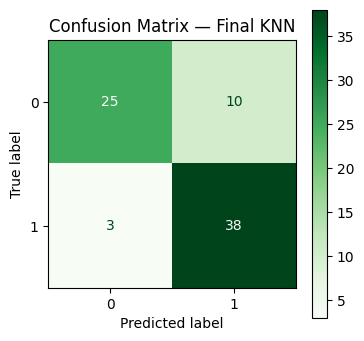

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=11, weights="uniform"))
])
best_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score
y_pred_best = best_model.predict(X_test)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, digits=3))

fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap="Greens")
ax.set_title("Confusion Matrix — Final KNN")
plt.show()


In [15]:
import gradio as gr
import pandas as pd

# Ensure best_model and X exist
assert 'best_model' in globals() and 'X' in globals(), "Train model first."

# Choose which inputs to expose
VISIBLE_FEATURES = ["age", "sex", "cp", "thalach"]

# Provide reasonable defaults for hidden features
DEFAULTS = {
    "trestbps": 130,   # resting BP
    "chol": 240,       # cholesterol
    "fbs": 0,          # fasting blood sugar > 120 mg/dl
    "restecg": 1,      # ST-T abnormality
    "exang": 0,        # exercise induced angina
    "oldpeak": 1.0,    # ST depression
    "slope": 1,        # slope of ST segment
    "ca": 0,           # number of major vessels
    "thal": 2          # 1=normal, 2=fixed, 3=reversible (we use 2 as default)
}

# Build a full input row from the 4 visible fields + defaults
def build_input(age, sex, cp, thalach):
    row = {
        "age": age,
        "sex": sex,
        "cp": cp,
        "thalach": thalach,
        **DEFAULTS
    }
    # Ensure final column order matches training
    row_ordered = {col: row[col] for col in list(X.columns)}
    return pd.DataFrame([row_ordered])

def predict_visible(age, sex, cp, thalach):
    xin = build_input(age, sex, cp, thalach)
    pred = best_model.predict(xin)[0]
    # KNN may or may not expose proba; try and display if available
    try:
        proba = best_model.predict_proba(xin)[0,1]
        score = f" | Risk: {proba:.2f}"
    except Exception:
        score = ""
    label = "Disease" if pred==1 else "No Disease"
    return f"{label}{score}"

with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue")) as demo:
    gr.Markdown("## Heart Disease Prediction")
    with gr.Row():
        with gr.Column(scale=1):
            age = gr.Slider(20, 90, value=54, step=1, label="Age")
            sex = gr.Radio(choices=[("Female",0), ("Male",1)], value=1, label="Sex")
            cp = gr.Dropdown(choices=[
                ("Typical angina",0), ("Atypical angina",1),
                ("Non-anginal pain",2), ("Asymptomatic",3)
            ], value=2, label="Chest pain type")
            thalach = gr.Slider(60, 220, value=150, step=1, label="Max heart rate (thalach)")
            btn = gr.Button("Predict", variant="primary")
        with gr.Column(scale=1):
            card = gr.HighlightedText(label="Result", combine_adjacent=True)
            note = gr.Markdown(
                "Defaults used: trestbps=130, chol=240, fbs=0, restecg=1, exang=0, oldpeak=1.0, slope=1, ca=0, thal=2"
            )
    out = gr.Textbox(label="Prediction", interactive=False)

    def on_click(age, sex, cp, thalach):
        return predict_visible(age, sex, cp, thalach)

    btn.click(on_click, inputs=[age, sex, cp, thalach], outputs=out)

demo.launch(inline=True, height=320)


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
